In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import math
from constants import *
from itertools import cycle, islice


1.975165611601485 -5.432815311836299e-14
1.4981602049005334 -3.446985237103088e-14
1.415544746749448 3.754649051498374e-14


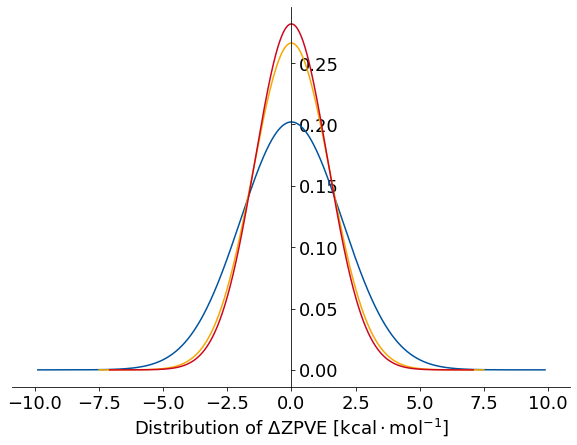

In [66]:
fontsize = 18
limits=[[-15,30]]
plt.style.use('rwth_colors.mplstyle')
def f(x,SD,mean):
    pi = math.pi
    #print(pi)
    #y = np.zeros(len(x))
    y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
    return y
list_plot = []
fig, ax = plt.subplots()
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(True)
ax.spines["right"].set_position(("data", 0))
ax.yaxis.tick_right()
par = ['ZPVE']
xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$']
label = [r'5',r'53 ',r'537']

j = 0
i = 0
folders = ['10','11','12']#,'2','3','4','5']\n",
for folder in folders:
    for rnd_state in [29]:#,0,29,56,100]:
        ML = np.genfromtxt(f'plots/{folder}/ZPVE_ML_Delta{rnd_state}.txt')
        xTB =np.genfromtxt(f'plots/{folder}/ZPVE_xTB_Delta{rnd_state}.txt')            
        p = np.polyfit(xTB,ML,1)
        ML = (ML-p[1])/p[0]
        for element in [list([list(ML),list(xTB)])]:



            if par[i] == 'ZPVE':
                array_xtb = ( np.array(element[0]) - np.array(element[1]))*627.5
                arr_i = 0
                array_xtb = list(array_xtb)

                while arr_i < len(element[0]):
                    if  element[1][arr_i]*627.5> 1000. or element[1][arr_i] == 0.:
                        array_xtb.pop(arr_i)
                        element[0].pop(arr_i)
                        element[1].pop(arr_i)

                    else:
                        arr_i += 1

            array_xtb = np.array(array_xtb)
            MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))

            mean =array_xtb.mean()
            
            dy2 = sum((array_xtb-array_xtb.mean())**2)
            SD = np.sqrt(dy2/len(array_xtb))
            SD = SD

            limits = [[mean-5*SD,mean+5*SD]]

            x = np.linspace(limits[i][0],limits[i][1],2000)
            print(SD,mean)
            #print(SD*349.76,mean*349.76)

            mean = array_xtb.mean()
            y = f(x,SD,mean)
            pl, = ax.plot(x,y,label = label[j])
            list_plot.append(pl)
            j+= 1

        if par[i] == 'wn':
            plt.xlabel(xlabel[i],fontsize = fontsize)
        else:
            plt.xlabel(xlabel[i],fontsize = fontsize)

        savename = f'ErrorDistNonZPE{par[i]}'
        plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")

        #plt.legend()
        plt.xlabel(r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$')

        plt.savefig('ErrorDist_example.png')
        plt.savefig('ErrorDist_example.svg')



0.9929843914523044
0.9946063176542531
0.9945204337680129


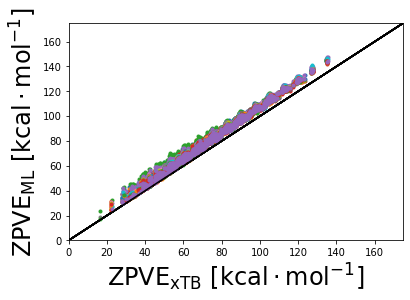

In [5]:
'''folders = ['plots/gdb7_all_full_features/','plots/gdb7_all/'
'plots/gdb7_all_proj/','plots/gdb7_all_full_features_rfr/','plots/gdb7_all_full_features_rfr2/']
'plots/init_test_set_rot/']#['plots/gdb7_100/','plots/gdb7_100_500estimator/','plots/gdb7_6000_6100/','plots/gdb7_200/']#init_test_set_rot\
'''
from scipy.stats import linregress

folders = ['10','11','12']#,'2','3','4','5']\n",
for folder in folders:
    R = 0
    for rnd_state in [46,0,29,56,100]:
        ML = np.genfromtxt(f'plots/{folder}/ZPVE_ML_Delta{rnd_state}.txt')
        xTB =np.genfromtxt(f'plots/{folder}/ZPVE_xTB_Delta{rnd_state}.txt')
        #35 einträge hat das erste train set\n",
        inlier = []
        outlier = []
        m,b,r,p,se = linregress(xTB,ML)
        R += r**2/5
        #p = np.polyfit(xTB,ML,1)
        #ML = (ML-p[1])/p[0]
        #print(p)
        #plt.plot(xTB*627.5,(ML-p[1])*627.5/p[0],'.',label='Adjusted')
        plt.plot(xTB*627.5,(ML)*627.5,'.')
        
        #x = np.linspace(0,200,1000)\n",
        #plt.plot(x,p[0]*x+p[1]*627.5,'k-.')\n",
        #plt.plot(xTB*627.5,(ML)*627.5,'.')\n",

        plt.plot([0.,180.],[0.,180.],'k')
        #plt.plot([0.,150.],[2.,152.],'k--')\n",
        #plt.plot([-0.,150.],[-2.,148.],'k--')\n",
        plt.xlim([0,175])
        plt.ylim([0,175])

        #plt.legend()
        plt.xlabel(r'$ \mathrm{ZPVE}_\mathrm{xTB}~[\mathrm{kcal \cdot mol^{-1}}]$',fontsize=24)
        plt.ylabel(r'$ \mathrm{ZPVE}_\mathrm{ML}~[\mathrm{kcal \cdot mol^{-1}}]$',fontsize=24)
        #plt.savefig('ZPEvZPE_example.png')
        #plt.savefig('ZPEvZPE_example.svg')
        #plt.savefig('ZPEvZPE_example.eps')
    print(R)

In [2]:
import numpy as np
import pickle
import pandas as pd
import math


0.029805449698725235
0.022866994926332634
0.020957136837822455


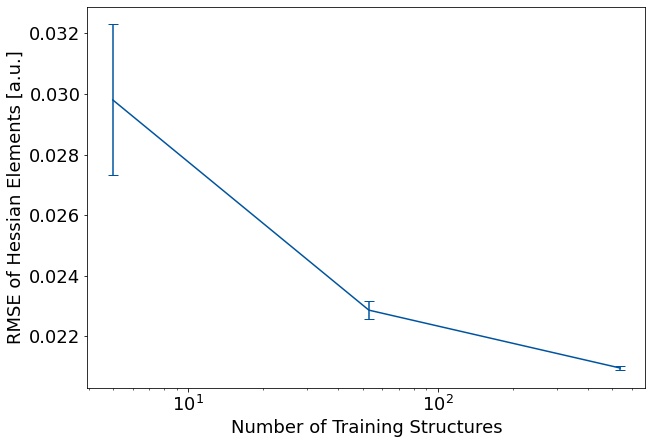

In [59]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
md = []
std = []
data = [5,53,537]#,537,1074]
folders = ['10','11','12']#,'6','7']
for folder in folders:
    MSE = np.sqrt(np.loadtxt(f'plots/{folder}/MSE_Hessian_Elements.txt'))
    #MSE = np.sqrt(np.loadtxt(f'plots/{folder}/ZPVE.txt'))

    MD = np.mean(MSE)
    STD = np.std(MSE)
    md.append(MD)
    std.append(STD)
    print(MD)
plt.errorbar(data,md,std,capsize=5)
plt.xlabel('Number of Training Structures')
plt.ylabel('RMSE of Hessian Elements [a.u.]')

plt.xscale('log')

2.9889799984320664 9.369881599973638
2.7610018588635183 8.720497581982833
2.9552402242492364 9.422117705386315
2.7969237326131626 8.795242294383934
3.1393708815073187 8.998517520316582
3.1887380491459667 8.24650808072542
3.1725693232921333 8.31105954134093
3.076936143075749 8.223560458479117
3.1522937057728964 8.09239560125112
3.0238416985198766 8.15171991919614
3.1919267450394138 7.973338855176955
3.178174219293771 8.03526616863158
3.1380453412115363 7.908986014382825
3.1549113298675264 8.092192575408063
3.168666020832071 7.865669742302956


TypeError: float() argument must be a string or a number, not 'Line2D'

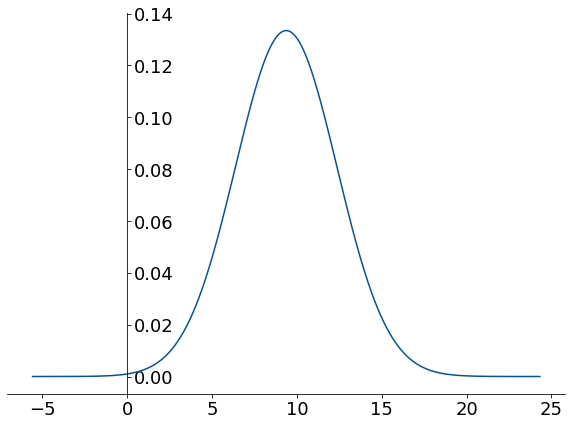

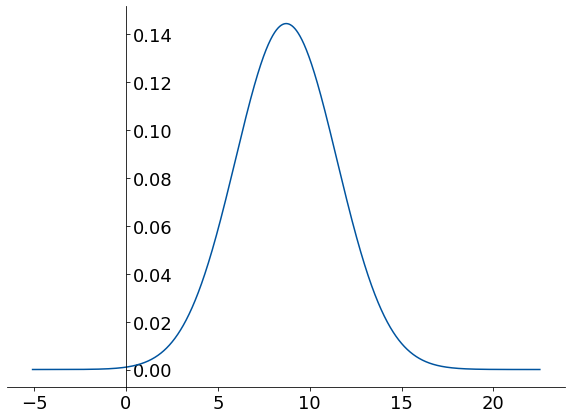

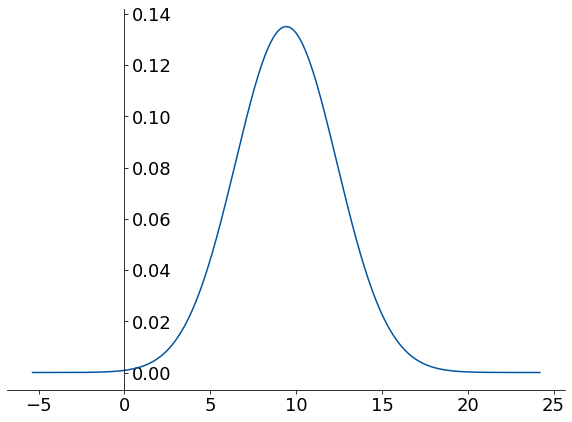

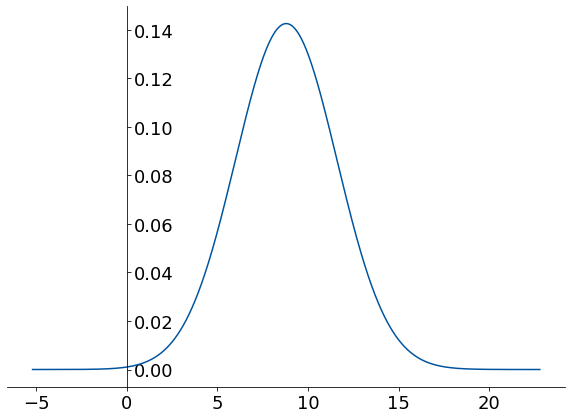

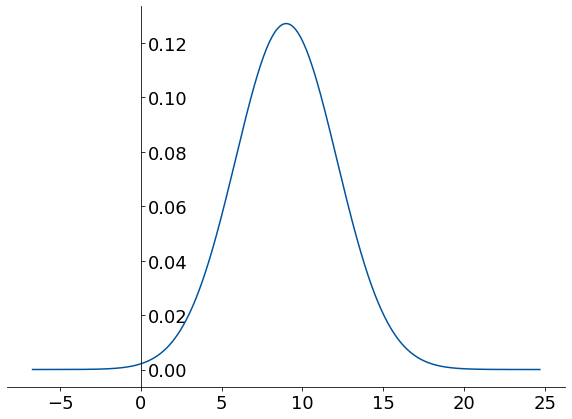

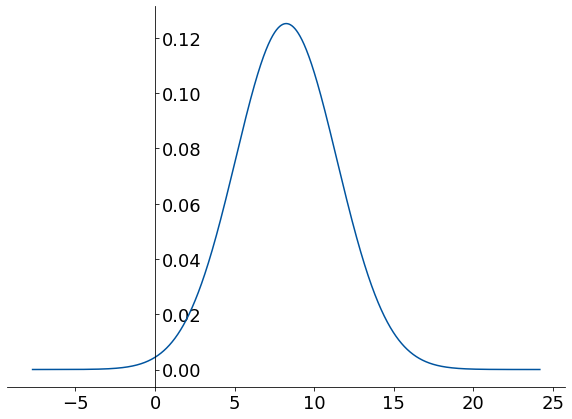

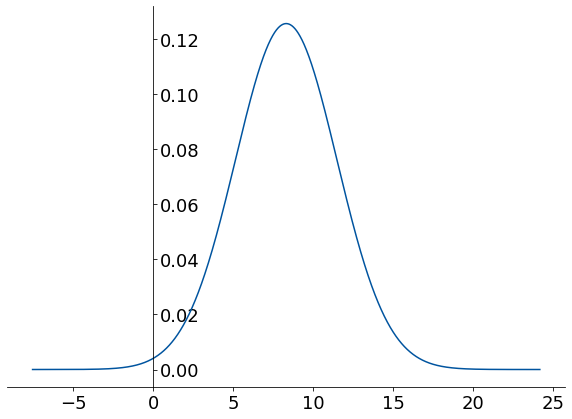

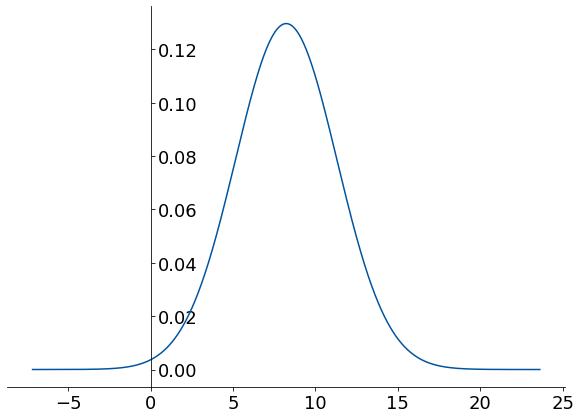

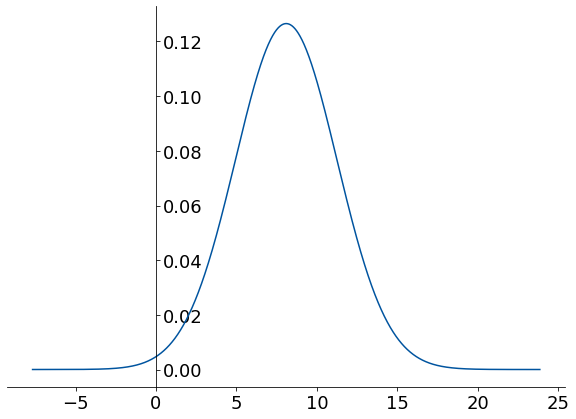

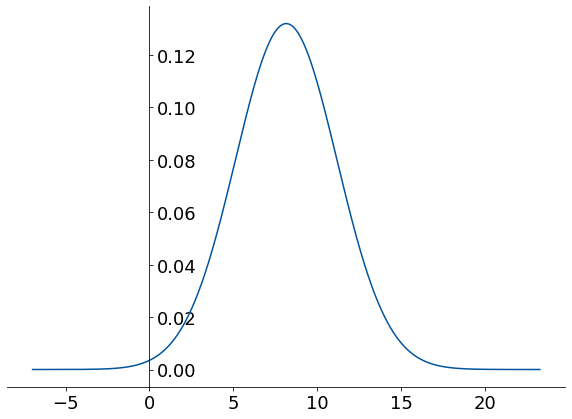

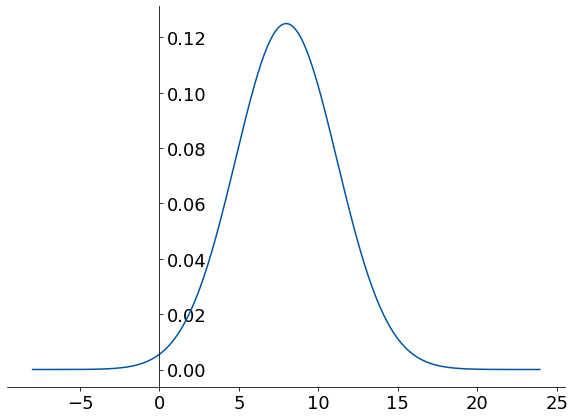

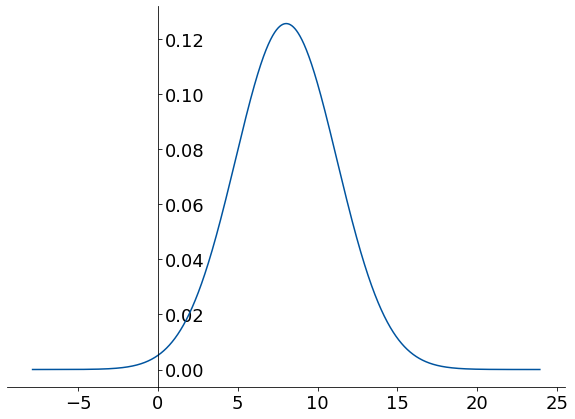

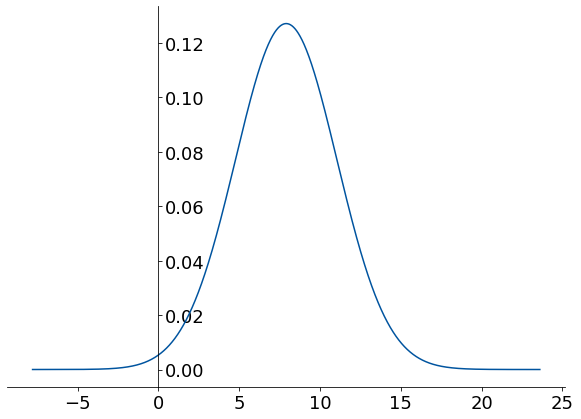

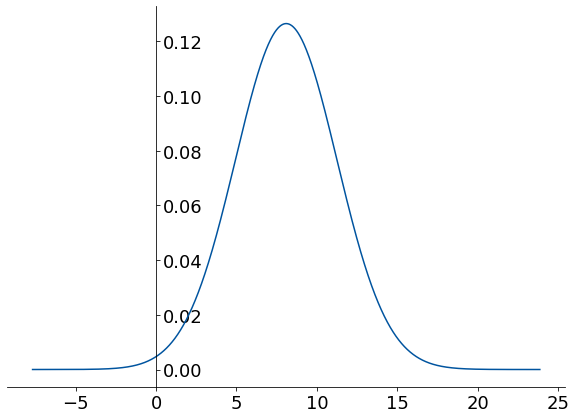

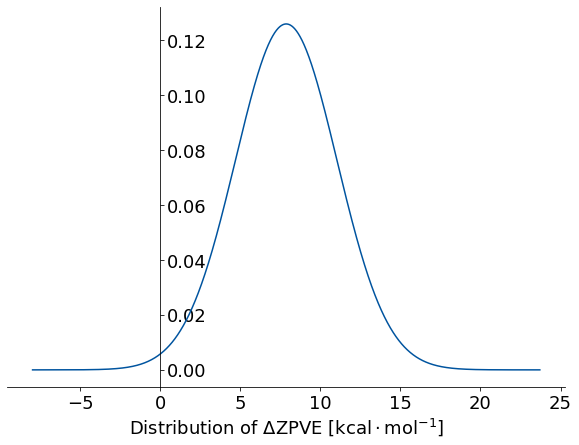

In [13]:
folders = ['5','4','6']#,'2','3','4','5']\n",
for folder in folders:
    for rnd_state in [46,0,29,56,100]:
        ML = np.genfromtxt(f'plots/{folder}/ZPVE_ML_Delta{rnd_state}.txt')
        xTB =np.genfromtxt(f'plots/{folder}/ZPVE_xTB_Delta{rnd_state}.txt')


        fontsize = 18
        limits=[[-15,30]]
        plt.style.use('rwth_colors.mplstyle')
        def f(x,SD,mean):
            pi = math.pi
            #print(pi)
            #y = np.zeros(len(x))
            y = 1.0/(SD*math.sqrt(2*pi))*np.exp(-0.5*((x-mean)/SD)**2)
            return y
        list_plot = []
        fig, ax = plt.subplots()
        ax.spines['left'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(True)
        ax.spines["right"].set_position(("data", 0))
        ax.yaxis.tick_right()
        par = ['ZPVE']
        xlabel = [r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$']
        label = [r'Inliers',r'Inliers + Outliers']

        j = 0
        i = 0
        for element in [list([list(ML),list(xTB)])]:

            if par[i] == 'ZPVE':
                array_xtb = ( np.array(element[0]) - np.array(element[1]))*627.5
                arr_i = 0
                array_xtb = list(array_xtb)

                while arr_i < len(element[0]):
                    if  element[1][arr_i]*627.5> 1000. or element[1][arr_i] == 0.:
                        array_xtb.pop(arr_i)
                        element[0].pop(arr_i)
                        element[1].pop(arr_i)

                    else:
                        arr_i += 1

            array_xtb = np.array(array_xtb)
            MD = sum(abs(array_xtb.mean()-array_xtb)/len(array_xtb))

            mean =array_xtb.mean()
            
            dy2 = sum((array_xtb-array_xtb.mean())**2)
            SD = np.sqrt(dy2/len(array_xtb))
            SD = SD

            limits = [[mean-5*SD,mean+5*SD]]

            x = np.linspace(limits[i][0],limits[i][1],2000)
            print(SD,mean)
            #print(SD*349.76,mean*349.76)

            mean = array_xtb.mean()
            y = f(x,SD,mean)
            pl, = ax.plot(x,y,label = label[j])
            list_plot.append(pl)
            j+= 1

if par[i] == 'wn':
    plt.xlabel(xlabel[i],fontsize = fontsize)
else:
    plt.xlabel(xlabel[i],fontsize = fontsize)

savename = f'ErrorDistNonZPE{par[i]}'
plt.setp(ax.yaxis.get_majorticklabels(), rotation=0, ha="left")

#plt.legend()
plt.xlabel(r'Distribution of $\Delta \mathrm{ZPVE}~[\mathrm{kcal \cdot mol^{-1}}]$')
plt.plot(list_plot)
#plt.savefig('ErrorDist_example.png')
#plt.savefig('ErrorDist_example.svg')

In [31]:
import matplotlib.pyplot as plt


def import_coord(file):
     with open(file) as myfile:
          head = [next(myfile) for x in range(2)]

     coord_var = pd.read_csv(file,sep = '\s+',skiprows = 2,header = None)
     coord_var.columns= ['atoms','x','y','z']
     return coord_var,head


def import_hessian(file,coord_var):
     LineList = []
     with open (file,'r') as fd:
          Lines = [line.rstrip('\n') for line in fd]
          for line in Lines[1:]:
               LineList += line.split()

     hess = np.zeros([len(coord_var['atoms'])*3,len(coord_var['atoms'])*3])

     i = 0
     for k in range(len(hess[0,:])):
          for l in range(len(hess[:,0])):
               hess[k,l] = float(LineList[i])
               i+=1
     return hess

-0.561245505 0.8465926099


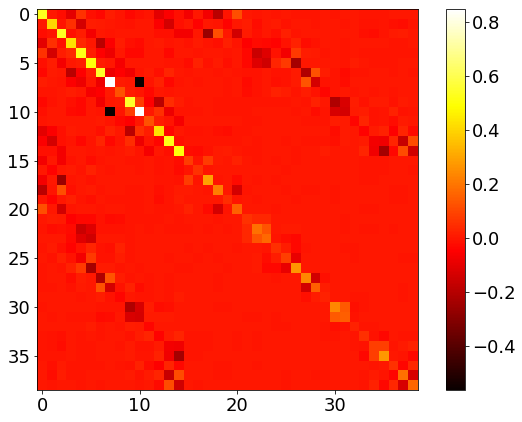

In [39]:
folder = "/home/gfeldmann/Documents/gdb7_comp/gdb7/70/"

coord,header = import_coord(f"{folder}xtbopt.xyz")
hessian =import_hessian(f"{folder}hessian",coord)

fig,ax = plt.subplots()
c = ax.imshow(hessian, cmap='hot')
fig.colorbar(c)


In [8]:
import pandas as pd
from class_sys_info import *
from joblib import dump ,load
from packages import *

In [13]:
from packages import *
import pickle

rnd_state = 46
Systems = []
folder = "/home/gfeldmann/Documents/gdb7_nonproj/"

mol_sys_idx = []
for mol in range(1):
    for sys in range(7164):
        mol_sys_idx.append([mol,sys])

test_train_split_idx = np.arange(0,len(mol_sys_idx),1)
train_idx, test_idx = train_test_split(test_train_split_idx,test_size=0.25,train_size=0.15,random_state=rnd_state)

with open(f'{folder}/Systems','rb') as f:
    for _ in range(7164):
        Systems.append(pickle.load(f))




In [10]:
from packages import *
import pickle

rnd_state = 46
Systems = []
folder = "/home/gfeldmann/Documents/gdb7_comp/"

mol_sys_idx = []
for mol in range(1):
    for sys in range(7164):
        mol_sys_idx.append([mol,sys])

test_train_split_idx = np.arange(0,len(mol_sys_idx),1)
train_idx, test_idx = train_test_split(test_train_split_idx,test_size=0.25,train_size=0.15,random_state=rnd_state)

print(sorted(train_idx)[0])

0


In [15]:
for i in [0]:
    X_hetero = []
    y_hetero = []

    X_homo = []
    y_homo = []

    X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed',train_rot=False,train_set =False)
    Systems[i].gen_Hessian_vector(train_rot=False,train_set =False)

    X_hetero.extend(X_hetero_temp)

    X_homo.extend(X_homo_temp)
    
    y_hetero.extend(Systems[i].H_AB_vec)
    y_homo.extend(Systems[i].H_AA_vec)
    

print(np.shape(X_homo))
print(np.shape(X_hetero))
print(np.shape(y_homo))
print(np.shape(y_hetero))

#print(f'Generated the Feature vectors. \nWall time: {round(wall_time_3 -wall_time_2)} s')
wall_time_3 =  time.time()

print(f'Fitting the Model.')
n_estimators_homo = 1000
n_estimators_het = 1000
max_depth_homo = 30
max_depth_het = 30 

print(f'Homo. Model uses: {n_estimators_homo} Estimators and \na maximal depth of {max_depth_homo}')

print(f'Het. Model uses: {n_estimators_het} Estimators and \na maximal depth of {max_depth_het}')

regr_homonuclear=  ExtraTreesRegressor(n_estimators = n_estimators_homo,random_state=rnd_state,bootstrap=True)

regr_heteronuclear = ExtraTreesRegressor(n_estimators = n_estimators_het,random_state=rnd_state,bootstrap=True)

regr_homonuclear.fit(X_homo,y_homo)
regr_heteronuclear.fit(X_hetero,y_hetero)

(45, 27)
(90, 169)
(45,)
(90,)
Fitting the Model.
Homo. Model uses: 1000 Estimators and 
a maximal depth of 30
Het. Model uses: 1000 Estimators and 
a maximal depth of 30


ExtraTreesRegressor(bootstrap=True, n_estimators=1000, random_state=46)

In [11]:
regr_homonuclear=  load(f'{folder}ETR_HOMO46.joblib')
regr_heteronuclear=  load(f'{folder}ETR_HETERO46.joblib')

In [15]:
for i in [0]:

    X_homo_temp,X_hetero_temp = Systems[i].gen_Feature(label = 'indexed')
    Systems[i].gen_Hessian_vector()

    y_homo_pred = regr_homonuclear.predict(X_homo_temp)

    y_hetero_pred = regr_heteronuclear.predict(X_hetero_temp)
    print(y_hetero_pred[0:9])

    Systems[i].get_pred_hessian(hessian_homo=y_homo_pred,hessian_hetero=y_hetero_pred,check =False)

    Systems[i].project_hessian(label='xTB')
    Systems[i].project_hessian(label='pred')

    #Systems[i].weight_hessian(label='xTB')
    #Systems[i].weight_hessian(label='pred')

    Systems[i].gen_eigenvalues()


    hessian = Systems[i].hessian
    hessian_pred = Systems[i].H_pred


[-4.32033968e-02 -2.72345056e-05 -1.98804324e-05  8.00627386e-05
 -4.33679338e-02  1.41005464e-05 -8.51164966e-06 -1.70388697e-04
 -2.97776073e-01]


In [6]:
for i in range(9):
    print(y_hetero_pred[i],y_hetero[i])
    

-0.04120734426689542 -0.04342126383397034
-0.0038659893364856577 -2.4216178292160324e-06
-0.0003069041571568976 -3.920015761459314e-06
2.33450159644114e-06 -2.2518792796181086e-06
-0.04186952318806226 -0.04341946891391167
-0.001251606763201119 -3.061856319158499e-06
-2.1614869536655247e-07 -1.655868263588154e-06
-0.00012367551627716006 -1.8357550702505773e-06
-0.2882638828969615 -0.29803933275211797


2.5145503496915632e-05


/tmp/ipykernel_217349/3448381613.py:19: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


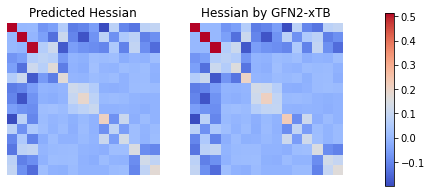

In [49]:
from sklearn.metrics import mean_squared_error

hdiff =hessian - hessian_pred
print(mean_squared_error(hessian.flatten(),hessian_pred.flatten()))
fig,(ax1,ax2) = plt.subplots(1,2)

ax1.set_title('Predicted Hessian') 
c = ax1.imshow(hessian_pred, cmap='coolwarm')
ax2.set_title(r'Hessian by GFN2-xTB') 

c = ax2.imshow(hessian, cmap='coolwarm')
ax1.axis('off')
ax2.axis('off')

cb_ax = fig.add_axes([1, 0.2, 0.02, 0.6])
fig.colorbar(c,cax=cb_ax)

plt.savefig('ComparisonHessian.eps')
fig.show()

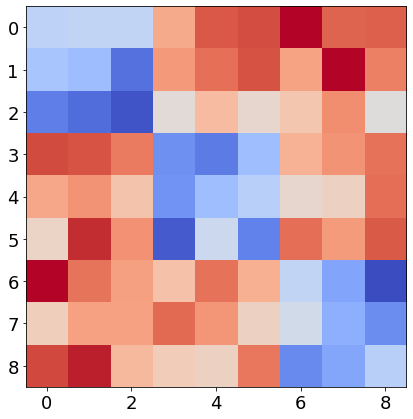

In [35]:
mat = np.array([[-1,-1,-1,1,1,1,1,1,1],
                [-1,-1,-1,1,1,1,1,1,1],
                [-1,-1,-1,1,1,1,1,1,1],
                [1,1,1,-1,-1,-1,1,1,1],
                [1,1,1,-1,-1,-1,1,1,1],
                [1,1,1,-1,-1,-1,1,1,1],
                [1,1,1,1,1,1,-1,-1,-1],
                [1,1,1,1,1,1,-1,-1,-1],
                [1,1,1,1,1,1,-1,-1,-1]])


mat1 = np.random.rand(9,9)
mat2 = mat1*mat
fig,ax = plt.subplots()
c = ax.imshow(mat2, cmap='coolwarm')
#fig.colorbar(c)